<h1 style="text-align:center; margin:0;">SHARP ANALYSIS: </h1>
<h3 style="text-align:center; margin-top:0;">Understanding Model Predictions</h3>

<p style="text-align:center;">The purpose of this notebook is to understand and explain the predictions made by the final Probability of Default (PD) model.
The TensorFlow model can predict the probability that a borrower may default, but it does not show why the prediction was made. SHAP (SHapley Additive Explanations) is used to show which features had the biggest effect on each prediction and which features have the most influence on credit risk overall.</p>

<p><b>Libraries Used;</b></p>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model

from sklearn.preprocessing import StandardScaler

import shap

In [56]:
#LOAD DATA 
#load the best version of the Pd model pd_baselinemodel_v2
best_pd_model = load_model("../models/pd_baselinemodel_v2.keras")
#load cleaned data 
data = pd.read_csv("..\data\lending_club_loan_data_cleaned.csv") 

<h2 style="text-align:center;">PREPROCESSING DATA FOR SHARP ANALYSIS</h2>

<p><b>1. Encode Traget Variable</b></p>

In [57]:
#ENCODING TARGET VARIABLE - loan amount 
def targetVariable(x):
    if(x=='Fully Paid'):
        return 1
    return 0
data['loan_status'] = data['loan_status'].apply(targetVariable) #apply func to all target variable

<p><b>2. Convert Categorical Variables to Numeric</b></p>

In [58]:
#CONVERT ALL CATEGORICAL VARIABLES TO NUMERIC 
# Start by listing all columns that are currently non-numeric
data.select_dtypes(['object']).columns

Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'purpose', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

<p style="margin:0;"><b>term</b></p>

In [59]:
# inspecting "term" variable 
data['term'].value_counts() # the output shows there are only 2 possible loan terms

# converting "term" variable to numeric 
data['term'] = data['term'].apply(lambda term: int(term[:3]))

<p style="margin:0;"><b>grade & subgrade</b></p>

In [60]:
#inspecting grade variable 
#Since every grade is already represented within sub_grade, keeping both variables would be redundant.
data = data.drop('grade',axis=1) # remove grade varaible 

#CREATE DUMMY VARIABLES from the sub_grade variable 
subgrade_dummies = pd.get_dummies(data['sub_grade'],drop_first=True)
data = pd.concat([data.drop('sub_grade',axis=1),subgrade_dummies],axis=1)
#converts the categorical variable into multiple binary columns.


<p style="margin:0;"><b>verification_status, application_type, initial_list_status, purpose</b>
<p>These variables need to be converted into dummy variables so they could be used by machine learning models.</p>

In [61]:
#create dummy variables
dummies = pd.get_dummies(data[['verification_status', 'application_type','initial_list_status','purpose' ]],drop_first=True)
#drop original columns 
data = data.drop(['verification_status', 'application_type','initial_list_status','purpose'],axis=1)
data = pd.concat([data,dummies],axis=1)

<p style="margin:0;"><b>home_ownership</b></p>

In [62]:
data['home_ownership'].value_counts() # output is 6 home ownership categories 

#combine rare categories
data['home_ownership']=data['home_ownership'].replace(['NONE', 'ANY'], 'OTHER')
#create dummy variables
dummies = pd.get_dummies(data['home_ownership'],drop_first=True)
#remove original column
data = data.drop('home_ownership',axis=1)
data = pd.concat([data,dummies],axis=1)

<p style="margin:0;"><b>address</b></p>
<p>Since almost every borrower has a different address, the full address is not very useful for identifying default patterns
Therefore, using feature engineering, the address is transformed into a ZIP code feature, which preserves location information while reducing the complexity of the data for the model.</p>

In [63]:
data['address'].value_counts() #output

#extract zip code from the address 
data['zip_code'] = data['address'].apply(lambda address:address[-5:])

#convert zip code into dummy variables 
dummies = pd.get_dummies(data['zip_code'],drop_first=True)
#remove original columns 
data = data.drop(['zip_code','address'],axis=1)
data = pd.concat([data,dummies],axis=1)

<p style="margin:0;"><b>issue_d</b></p>
<p>The issue date variable was removed because it could introduce data leakage into the model. Data leakage occurs when a model uses information that would not be available at the time a lending decision is made. Therefore, this feature is dropped to ensure that the model is trained using only information available at the time of loan application.</p>

In [64]:
data = data.drop('issue_d',axis=1)

<p style="margin:0;"><b> earliest_cr_line </b></p>
<p>This variable records the month and year a borrower first opened a credit account.Since machine learning models cannot effectively use dates stored as text, the year is extracted and converted into a numerical feature.</p>

In [65]:
data['earliest_cr_line'].value_counts() # output

#extract 4 last characters from each date (the year) 
data['earliest_cr_year'] = data['earliest_cr_line'].apply(lambda date:int(date[-4:]))
data = data.drop('earliest_cr_line',axis=1)

In [66]:
#listing all columns that are currently non-numeric
data.select_dtypes(['object']).columns

Index([], dtype='object')

<h2 style="text-align:center;">SHARP Analysis</h2>

In [67]:
#split features and Target 
X = data.drop("loan_status",axis=1)
y = data["loan_status"]

#Sclae features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
#Create Sharp Background
background_data = X_scaled[np.random.choice(X_scaled.shape[0],100,replace=False)]

#Create SHARP explainer 
explainer = shap.KernelExplainer(best_pd_model.predict,background_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [69]:
#Calculate Sharp Values 
sample_data = X_scaled[:100]
shap_values = explainer.shap_values(sample_data)

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step


  1%|          | 1/100 [00:11<18:13, 11.04s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
6763/6763 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


  2%|▏         | 2/100 [00:24<19:59, 12.24s/it]

...

 98%|█████████▊| 98/100 [33:47<00:51, 25.90s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
6769/6769 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step


 99%|█████████▉| 99/100 [34:13<00:25, 25.73s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
6763/6763 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step


100%|██████████| 100/100 [34:37<00:00, 20.78s/it]


<p><b>Global Feature Importance Summary Plot</b></p>

In [70]:
# Remove the unnecessary output dimension
shap_values_2d = shap_values.squeeze(-1)
print(shap_values_2d.shape)

(100, 78)


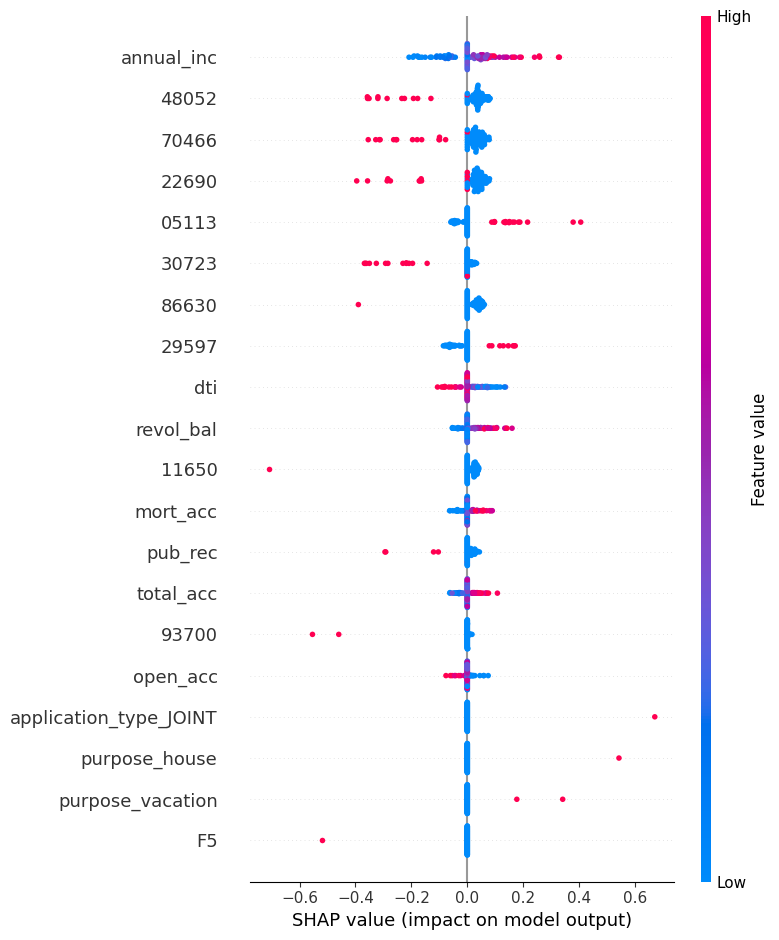

In [71]:
shap.summary_plot(shap_values_2d,sample_data, feature_names=X.columns)

<p style="margin:0;">The SHAP Summary Plot shows which features have the biggest effect on the model's Probability of Default (PD) predictions. Some of the most important features are</p>
<ul style="margin:0;">
    <li><b>annual income (annual_inc)</b> – This was one of the most important features. Higher income can mean that a borrower has more money available to repay the loan, while lower income may indicate higher risk.</li>
    <li><b>public records (pub_rec)</b> – This includes negative financial records such as bankruptcies. More public records can indicate previous financial problems.</li>
    <li><b>revolving balance (revol_bal)</b> – A higher revolving balance can show that the borrower has more outstanding credit, which may increase financial pressure.</li>
    <li><b>debt-to-income ratio (DTI)</b> – A higher DTI means more of the borrower's income is already going towards debt. This can make it harder to manage another loan and increase default risk.</li>
    <li><b>total accounts (total_acc)</b> – This shows the number of credit accounts a borrower has had and gives the model an idea of their credit history and experience.</li>
</ul>
<p style="margin:0;">The further a point is from zero, the more influence that feature has on the prediction. Positive SHAP values increase the predicted default risk, while negative values reduce it. Overall, the model mainly uses income, existing debt, credit usage, and credit history when predicting default risk. These factors help the model identify borrowers who may have a higher chance of struggling with repayments.</p>
<br>

<p><b>Feature Importance Table</b></p>
<p>The Feature Importance Table shows which features have the biggest influence on the model's PD predictions. Higher importance scores mean that the feature has a greater effect on the model's predictions. This helps identify the main factors contributing to credit risk.</p>

In [83]:
feature_importance = pd.DataFrame({"Feature": X.columns,"Importance": np.abs(shap_values_2d).mean(axis=0)})

# Remove features names that conatin numbers 
feature_importance = feature_importance[~feature_importance["Feature"].astype(str).str.contains(r"\d")]

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)

feature_importance.head(10)

,Feature,Importance
4,annual_inc,0.078717
5,dti,0.029901
8,revol_bal,0.029284
11,mort_acc,0.017947
7,pub_rec,0.017613
10,total_acc,0.017397
6,open_acc,0.007384
50,application_type_JOINT,0.006708
56,purpose_house,0.005426
63,purpose_vacation,0.005185


In [84]:
#save feature importance table 
feature_importance.to_csv("../outputs/feature_importance.csv",index=False)

<p><b>Visualize Top Risk Drivers</b></p>

Text(0.5, 0, 'Average SHAP Importance')

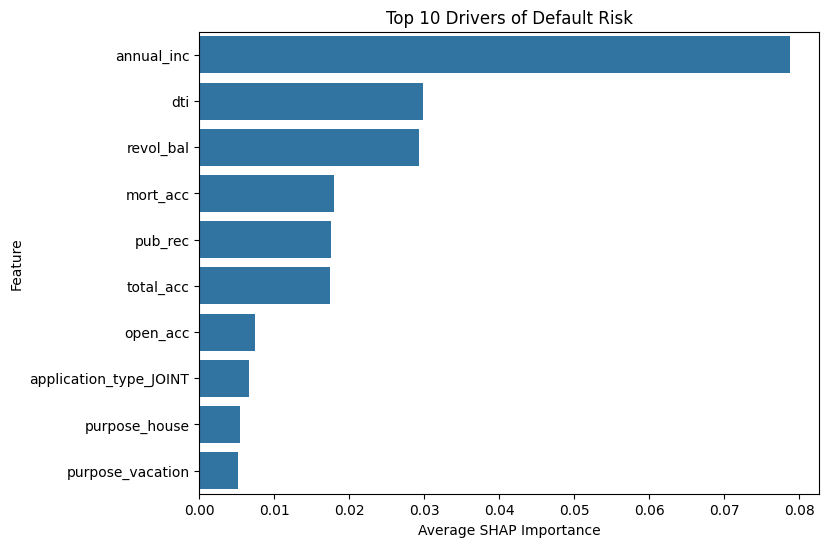

In [85]:
# Top 10 Features
top_features = feature_importance.head(10)
plt.figure(figsize=(8,6))

sns.barplot(data=top_features,x="Importance",y="Feature")

plt.title("Top 10 Drivers of Default Risk")
plt.xlabel("Average SHAP Importance")
#plt.ylabel("Feature")
#plt.show()

<p>The Top Risk Drivers chart shows the features that have the biggest influence on the model's PD predictions. Annual income (annual_inc) is the most important feature, followed by DTI, revolving balance, mortgage accounts, public records, and total accounts</p>